In [1]:
!pip install qiskit qiskit-aer pylatexenc

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

# Publish-quality dark mode styling
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", font_scale=1.2)
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.facecolor': '#121212',
    'figure.facecolor': '#121212'
})

### Paso 1: Preparación del Estado
Preparamos el qubit $q_0$ en el estado que queremos teletransportar (en este caso $|1\rangle$).

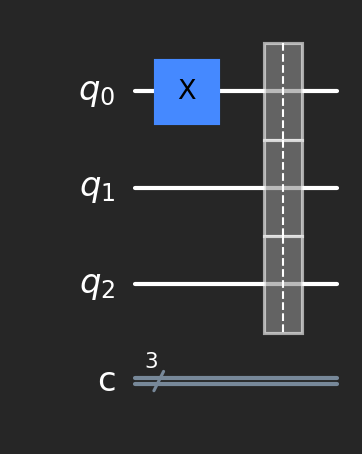

In [2]:
qr = QuantumRegister(3, name="q")
cr = ClassicalRegister(3, name="c")
step_circuit = QuantumCircuit(qr, cr)

step_circuit.x(0)
step_circuit.barrier()

display(step_circuit.draw(output='mpl', style='iqp-dark'))

### Paso 2: Creación del par EPR
Entrelazamos $q_1$ y $q_2$ para crear el canal cuántico.

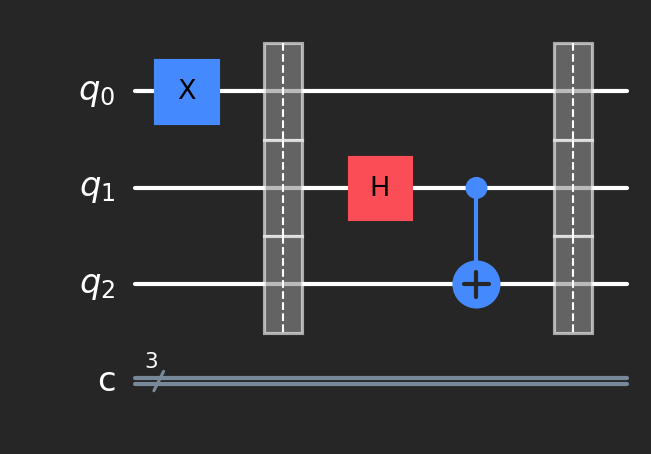

In [3]:
step_circuit.h(1)
step_circuit.cx(1, 2)
step_circuit.barrier()

display(step_circuit.draw(output='mpl', style='iqp-dark'))

### Paso 3: Operaciones de Alice
Alice aplica una compuerta CNOT y Hadamard a sus qubits.

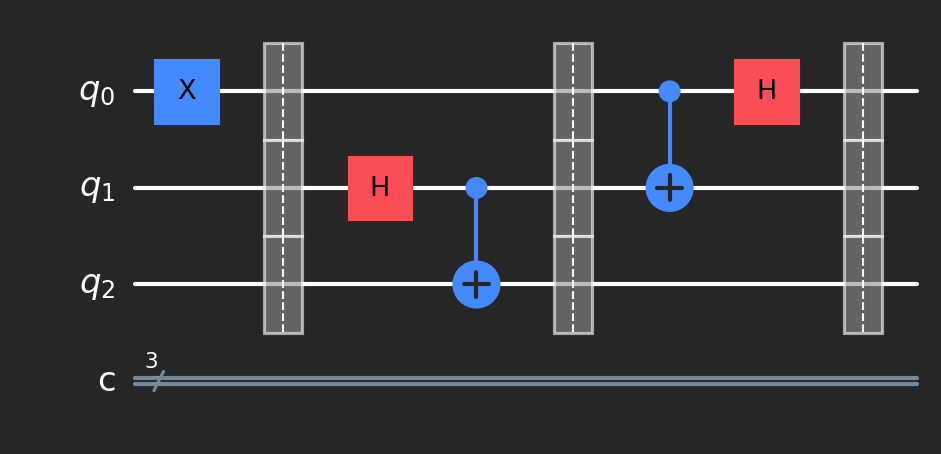

In [4]:
step_circuit.cx(0, 1)
step_circuit.h(0)
step_circuit.barrier()

display(step_circuit.draw(output='mpl', style='iqp-dark'))

### Paso 4: Medición y Comunicación Clásica
Alice mide sus qubits para obtener dos bits clásicos.

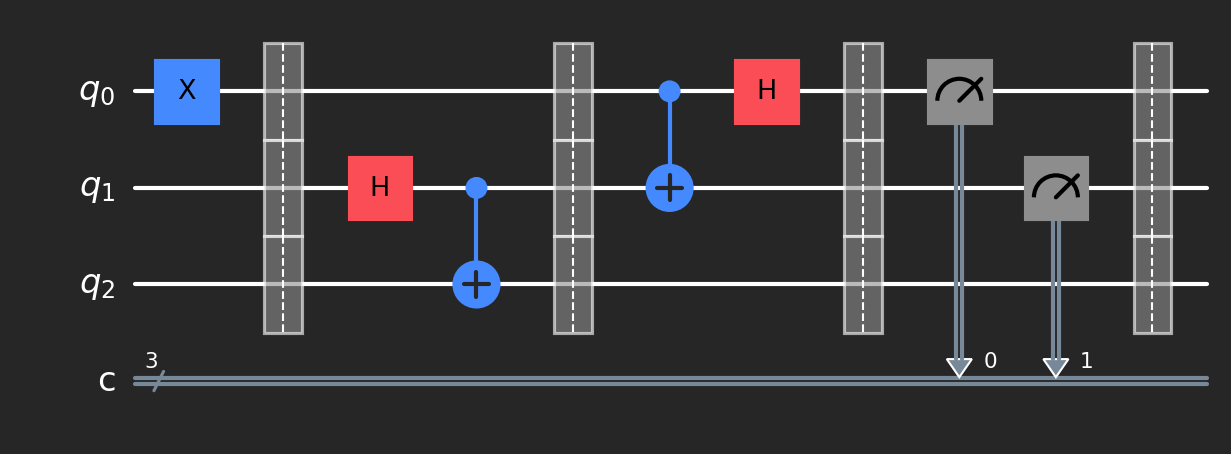

In [5]:
step_circuit.measure([0, 1], [0, 1])
step_circuit.barrier()

display(step_circuit.draw(output='mpl', style='iqp-dark'))

### Paso 5: Correcciones Condicionales de Bob
Bob aplica correcciones basadas en los resultados de Alice.

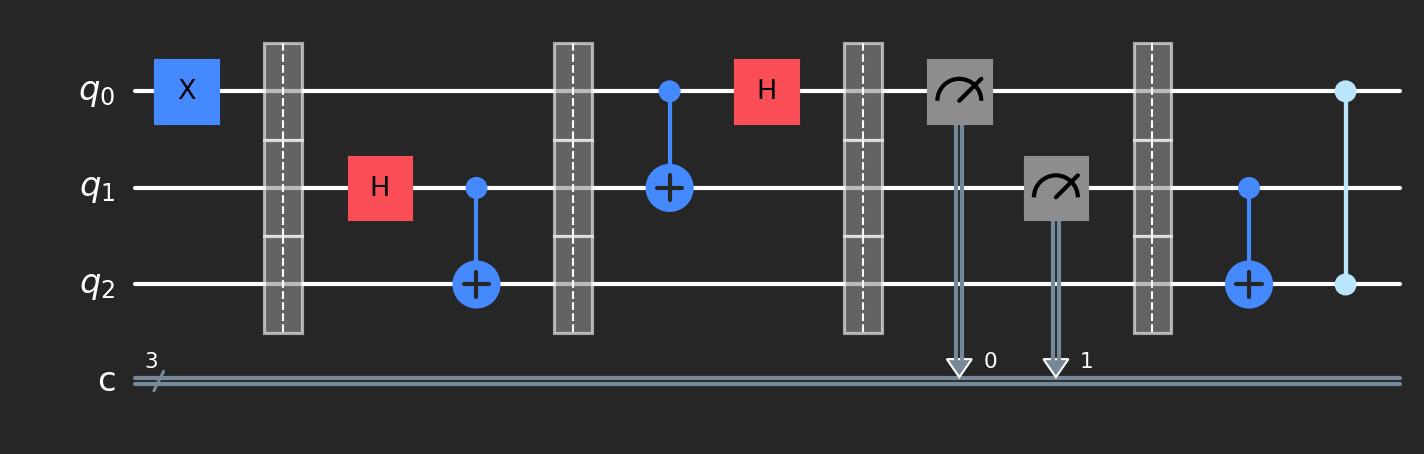

In [6]:
step_circuit.cx(1, 2)
step_circuit.cz(0, 2)

display(step_circuit.draw(output='mpl', style='iqp-dark'))

### Paso 6: Verificación
Medimos el qubit de Bob para verificar la teletransportación.

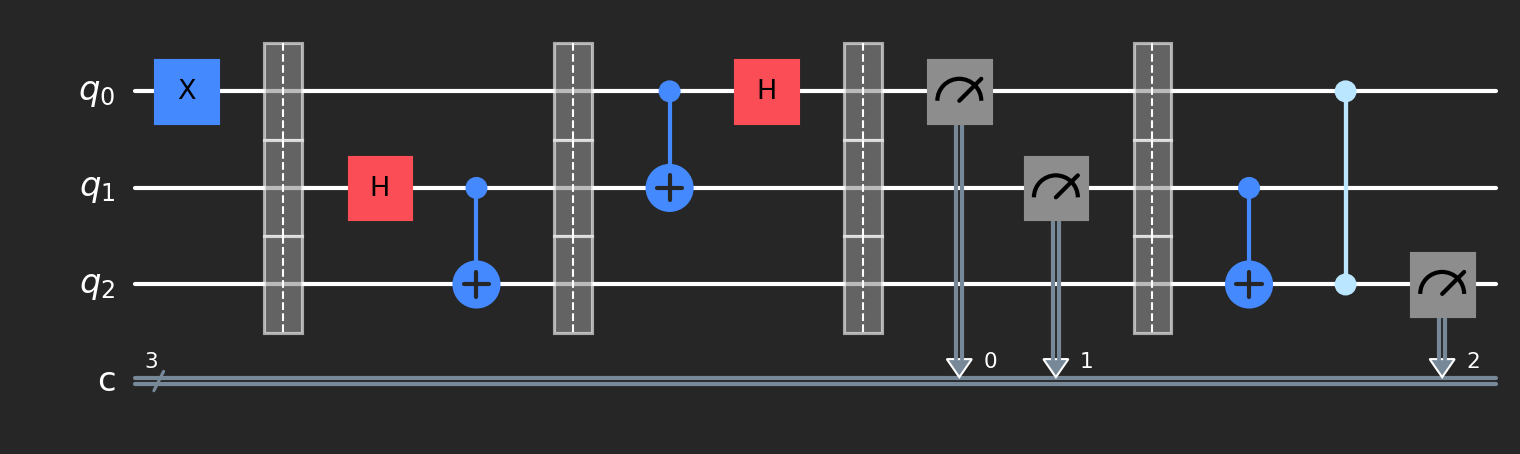

In [7]:
step_circuit.measure([2], [2])

display(step_circuit.draw(output='mpl', style='iqp-dark'))

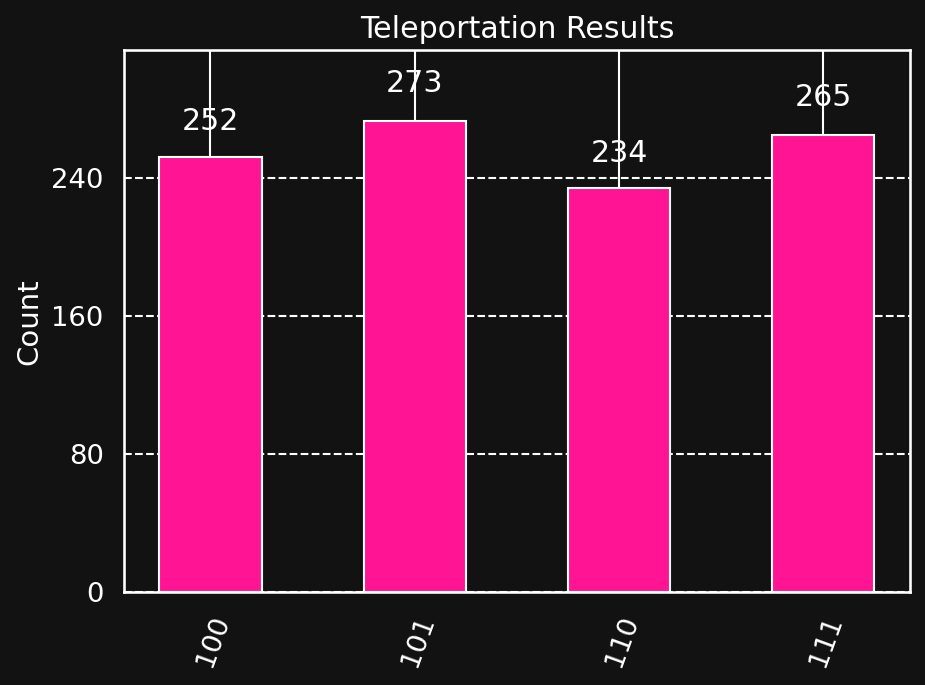

In [9]:
def simulate_and_visualize(circuit: QuantumCircuit, shots: int = 1024):
    """
    Executes the given circuit on a QASM simulator and plots the outcome.

    Args:
        circuit (QuantumCircuit): The circuit to run.
        shots (int): Number of experimental shots.
    """
    # Use backend.run() instead of the deprecated execute() function
    simulator = Aer.get_backend('qasm_simulator')
    job = simulator.run(circuit, shots=shots)
    result = job.result()
    counts = result.get_counts(circuit)

    # Generate the probability histogram
    fig = plot_histogram(counts, title="Teleportation Results", color='#ff1493')

    # Apply matching dark theme configuration to the resulting figure
    fig.patch.set_facecolor('#121212')
    for ax in fig.axes:
        ax.set_facecolor('#121212')
        # Set labels and title to white
        ax.title.set_color('white')
        ax.xaxis.label.set_color('white')
        ax.yaxis.label.set_color('white')
        ax.tick_params(axis='x', colors='white')
        ax.tick_params(axis='y', colors='white')

        # Adjust the top margin to prevent number overlap
        ax.set_ylim(0, max(counts.values()) * 1.15)

        # Update text inside the plot to white
        for text in ax.texts:
            text.set_color('white')

    display(fig)

# Run the simulation using the active circuit variable 'step_circuit'
simulate_and_visualize(step_circuit)